<a href="https://colab.research.google.com/github/jammy-0207/EMSC2010_Individual_Assignment_A3/blob/main/EMSC2010_Individual_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Individual Project

## 1. Project Overview

Project week: Week 12

Project title: Quanitifying Pacific Ocean Acidification: How have long-term changes in surface ocean carbonate chemistry altered future projections?

Datasets used (name and source):

Name of the dataset used: Global Ocean Data Analysis Project Version 2.2021 (GLODAPv2.2021) – Pacific Ocean subset

Link to dataset (before it was cleaned): https://1drv.ms/x/c/9c4c142238c6bf2b/IQApHTj3RjHuS6hVrRE4Mu4qAZqwkhLG5jLRdEI5xxAwHIo?e=WkHjDe

Link to dataset (after it was cleaned): https://1drv.ms/x/c/9c4c142238c6bf2b/IQDjYtykhwnDS5mugYE3xcTyAdLEyp1cG4d6xNUgkOqny3Q?e=Svhzjy

## 2. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

#  How have Pacific surface ocean pH levels changed over time, and what can historical trends reveal about future ocean acidification?

Modules used:


1.   Time series analysis
2.   Numerical modelling

1.   Monte Carlo simulation






## Dataset and Cleaning Summary

This project uses the GLODAPv2.2021 Pacific Ocean dataset, which contains observational ocean chemistry measurements from the Pacific Ocean. The original dataset was cleaned to focus on surface ocean acidification indicators.

Only surface water observations were retained because ocean acidification is most directly linked to  CO₂ exchange between air and sea at the ocean surface. The cleaned dataset includes pH, dissolved inorganic carbon, alkalinity, temperature, salinity, depth, latitude, longitude and date. Missing or invalid values were removed before analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [ ]:
df = pd.read_csv("ocean_acidification_pacific_cleaned.csv")
df.head()

,date,latitude,longitude,depth_m,temperature_C,salinity,dissolved_inorganic_carbon,alkalinity,pH_insitu,pH_25C
0,25-08-1973,34.175,-127.90,1.0,17.600,33.085,1969.7,2209.4,8.0850,7.9733
1,30-08-1973,33.100,-139.57,7.0,21.751,34.646,1987.7,2287.4,8.1005,8.0515
2,05-09-1973,31.378,-150.03,2.0,23.560,34.881,1987.7,2294.4,8.0804,8.0587
3,08-09-1973,22.160,-153.84,10.0,25.500,35.173,1970.7,2347.4,8.1491,8.1570
4,18-09-1973,30.000,-159.84,7.0,25.241,35.471,1957.7,2325.4,8.1399,8.1438


In [ ]:
#CONVERT DATE COLUMN

df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.head()

/tmp/ipykernel_1403/1311387697.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


,date,latitude,longitude,depth_m,temperature_C,salinity,dissolved_inorganic_carbon,alkalinity,pH_insitu,pH_25C,year,month
0,1973-08-25,34.175,-127.90,1.0,17.600,33.085,1969.7,2209.4,8.0850,7.9733,1973,8
1,1973-08-30,33.100,-139.57,7.0,21.751,34.646,1987.7,2287.4,8.1005,8.0515,1973,8
2,1973-09-05,31.378,-150.03,2.0,23.560,34.881,1987.7,2294.4,8.0804,8.0587,1973,9
3,1973-09-08,22.160,-153.84,10.0,25.500,35.173,1970.7,2347.4,8.1491,8.1570,1973,9
4,1973-09-18,30.000,-159.84,7.0,25.241,35.471,1957.7,2325.4,8.1399,8.1438,1973,9


In [ ]:
#CREATE ANNUAL MEAN DATASET

annual = df.groupby('year').agg(
    mean_pH = ('pH_insitu', 'mean'),
    mean_DIC = ('dissolved_inorganic_carbon', 'mean'),
    mean_alkalinity = ('alkalinity', 'mean'),
    mean_temperature = ('temperature_C', 'mean'),
    mean_salinity = ('salinity', 'mean'),
    n_observations = ('pH_insitu', 'count')
).reset_index()

annual.head()

,year,mean_pH,mean_DIC,mean_alkalinity,mean_temperature,mean_salinity,n_observations
0,1973,8.118983,1949.004348,2278.226087,23.555000,34.567783,23
1,1974,8.127331,1993.768966,2308.020690,20.421345,34.962793,29
2,1991,8.108045,2001.057983,2326.134454,22.955529,35.321857,119
3,1992,8.079006,2013.574442,2284.127968,19.144728,34.464492,497
4,1993,8.083412,1992.170499,2255.355315,18.738165,33.996464,461


## Annual Mean Dataset

The cleaned observations were grouped by year to create an annual mean time series. This helps in reducing short-term variability and irregular sampling effects, making it easier to observe long-term changes in Pacific surface ocean pH.

The number of observations per year was also calculated to show how sampling effort varied across the dataset.

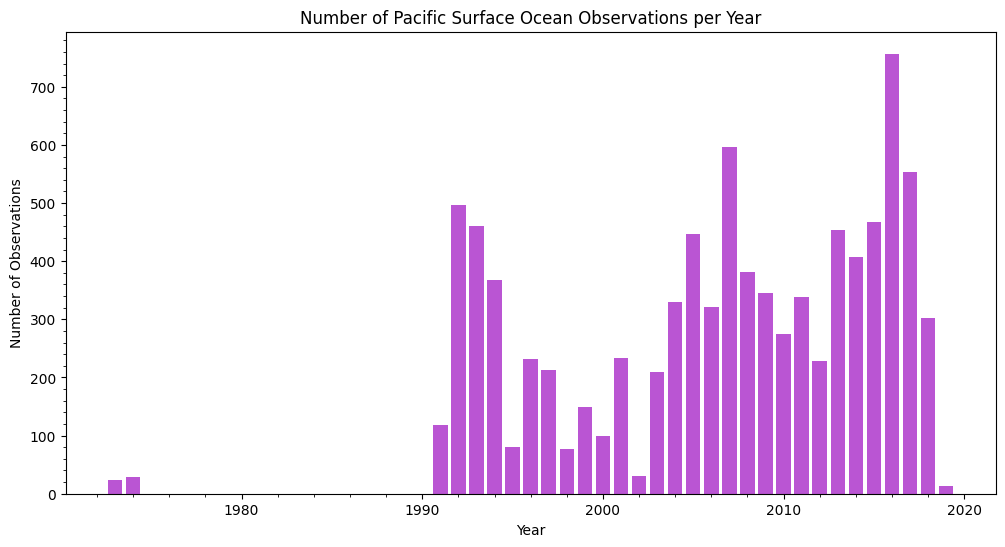

In [ ]:
#PLOT NUMBER OF OBSERVATIONS PER YEAR

plt.figure(figsize=(12,6))
plt.bar(annual['year'], annual['n_observations'], color='mediumorchid')
plt.xlabel('Year')
plt.ylabel('Number of Observations')
plt.title('Number of Pacific Surface Ocean Observations per Year')
plt.minorticks_on()
plt.show()

/tmp/ipykernel_1403/920646074.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-o" (-> color='k'). The keyword argument will take precedence.
  plt.plot(annual['year'], annual['mean_pH'], 'k-o', color='darkcyan', markerfacecolor='aquamarine', markeredgecolor='forestgreen')
/tmp/ipykernel_1403/920646074.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


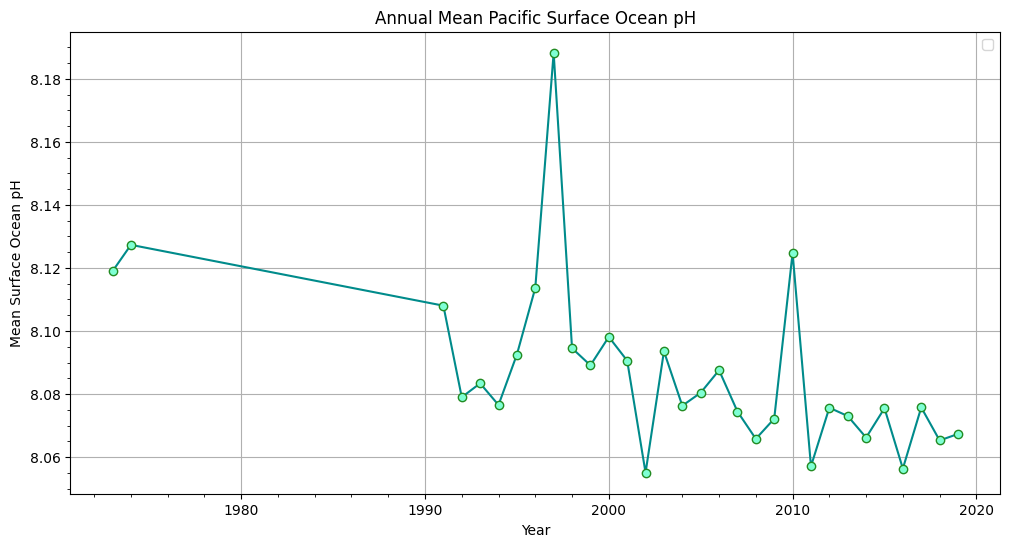

In [ ]:
#PLOT ANNUAL MEAN pH TIME SERIES

plt.figure(figsize=(12,6))
plt.plot(annual['year'], annual['mean_pH'], 'k-o', color='darkcyan', markerfacecolor='aquamarine', markeredgecolor='forestgreen')
plt.xlabel('Year')
plt.ylabel('Mean Surface Ocean pH')
plt.title('Annual Mean Pacific Surface Ocean pH')
plt.grid(True)
plt.legend()
plt.minorticks_on()
plt.show()

## Time Series Interpretation

The annual mean pH time series shows how Pacific surface ocean pH has differed through a particular time period. A gradual decline in pH demonstrates increasing ocean acidification, as lower pH indicates a higher concentration of hydrogen ions in seawater.

Because the dataset includes observations from a broad Pacific region rather than a single monitoring station, year-to-year variation may partly show variation in sampling location, cruise timing and oceanographic conditions.

In [ ]:
#CONVERT TO NUMPY ARRAYS

time = annual['year'].values.astype(float)
pH = annual['mean_pH'].values.astype(float)

DIC = annual['mean_DIC'].values.astype(float)
alkalinity = annual['mean_alkalinity'].values.astype(float)
temperature = annual['mean_temperature'].values.astype(float)
salinity = annual['mean_salinity'].values.astype(float)

In [ ]:
#DEFINE FUNCTION FOR FREQUENCY SPECTRUM

def freq_spectrum(time, signal):
  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time), np.max(time), n)
  y = np.interp(x, time, signal)

  sample_rate = 1/(x[1] - x[0]) #sampling rate
  fft_vals = np.fft.rfft(y) #FFT values
  freqs = np.fft.rfftfreq(n, d=1/sample_rate) #FFT frequencies

  amplitude = (2/n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

In [ ]:
#CALCULATE FREQUENCY SPECTRUM FOR pH

freqs, amplitude = freq_spectrum(time, pH)

/tmp/ipykernel_1403/68111051.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(freqs, amplitude, 'k', color='midnightblue')
/tmp/ipykernel_1403/68111051.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


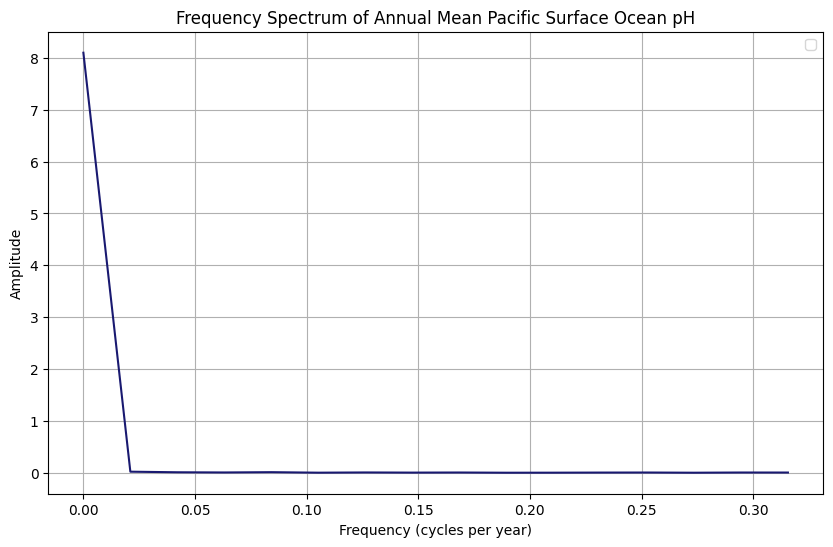

In [ ]:
#PLOT FREQUENCY SPECTRUM

plt.figure(figsize=(10,6))
plt.plot(freqs, amplitude, 'k', color='midnightblue')
plt.xlabel('Frequency (cycles per year)')
plt.ylabel('Amplitude')
plt.title('Frequency Spectrum of Annual Mean Pacific Surface Ocean pH')
plt.grid(True)
plt.legend()
plt.minorticks_on
plt.show()

In [ ]:
#DEFINE LOW-PASS FILTER FUNCTION

def lowpass_filter(time, signal, cutoff):
  n = len(time)

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time), np.max(time), n)
  y = np.interp(x, time, signal)

  sample_rate= 1/(x[1] - x[0])
  fft_vals = np.fft.rfft(y)
  freqs = np.fft.rfftfreq(n, d=1/sample_rate)

  #remove high-frequency variation
  fft_vals[freqs > cutoff] = 0.0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time))

  return x, filtered_signal

In [ ]:
#APPLY LOW-PASS FILTER TO pH DATA

cutoff = 0.15 #keeps long-term variation and removes short-term noise

time_smooth, pH_smooth = lowpass_filter(time, pH, cutoff)

## Low-Pass Filter Interpretation

A low-pass filter was applied to decrease constant short yet periodic variance and point out the long-term pH signal. This helps separate broad acidification trends from year-to-year noise in the observational record.



/tmp/ipykernel_1403/585531738.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  plt.plot(time, pH, 'ko', label='Annual mean pH', color='crimson')
/tmp/ipykernel_1403/585531738.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(time_smooth, pH_smooth, 'k-', color='teal', linewidth=2.5, label='Filtered annual mean pH')


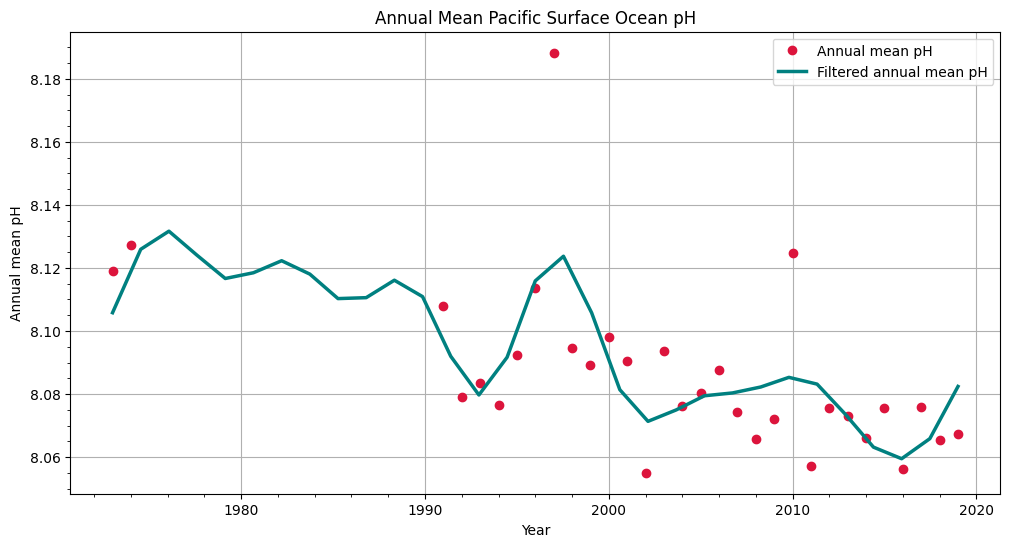

In [ ]:
#PLOT RAW AND FILTERED pH TIME SERIES

plt.figure(figsize=(12,6))
plt.plot(time, pH, 'ko', label='Annual mean pH', color='crimson')
plt.plot(time_smooth, pH_smooth, 'k-', color='teal', linewidth=2.5, label='Filtered annual mean pH')
plt.xlabel('Year')
plt.ylabel('Annual mean pH')
plt.title('Annual Mean Pacific Surface Ocean pH')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.show()


In [ ]:
#LINEAR TREND MODEL FOR pH

slope, intercept, r_value, p_value, std_err = linregress(time, pH)

print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", r_value**2)
print("P-value:", p_value)
print("Standard error:", std_err)

Slope: -0.0013126489691990119
Intercept: 10.716377533413246
R-squared: 0.30939972680723565
P-value: 0.0011569564796368515
Standard error: 0.00036416903294294244


## Linear Trend Interpretation

A linear regression model was implemented to the annual mean pH data to estimate the average rate of pH change over time. The slope represents the estimated annual change in surface ocean pH.

A negative slope would indicate declining pH over time, which remains consistent with ocean acidification. The p-value and R² value help assess and examine whether the trend is statistically meaningful and how much of the pH variation is explained by a single year alone.

In [ ]:
#CALCULATE FITTED pH VALUE

pH_fit = slope * time + intercept

/tmp/ipykernel_1403/1551964412.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  plt.plot(time, pH, 'ko', label='Annual mean pH', color='indigo')
/tmp/ipykernel_1403/1551964412.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(time, pH_fit, 'k-', color='orchid', linewidth=2.5, label='Linear trend')


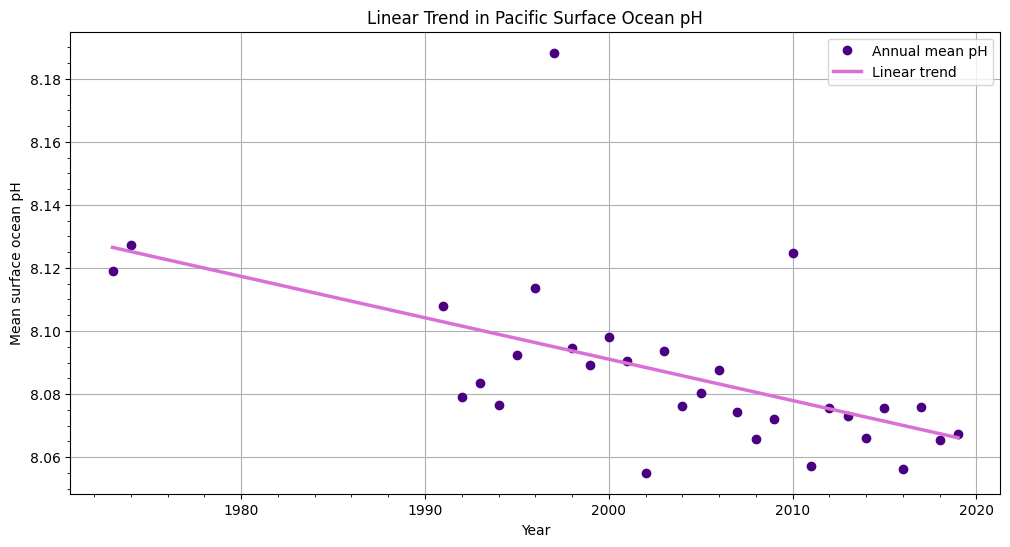

In [ ]:
#PLOT pH DATA WITH LINEAR TREND

plt.figure(figsize=(12,6))
plt.plot(time, pH, 'ko', label='Annual mean pH', color='indigo')
plt.plot(time, pH_fit, 'k-', color='orchid', linewidth=2.5, label='Linear trend')
plt.xlabel('Year')
plt.ylabel('Mean surface ocean pH')
plt.title('Linear Trend in Pacific Surface Ocean pH')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.show()

In [ ]:
#INTERPRET YEARLY pH CHANGE

print("Estimated annual pH change:", slope)

total_change = slope * (time.max() - time.min())
print("Estimated total pH change across study period:", total_change)

Estimated annual pH change: -0.0013126489691990119
Estimated total pH change across study period: -0.060381852583154545


In [ ]:
 #NUMERICAL MODELLING: PROJECTION OF FUTURE pH VALUES

 future_years = np.arange(int(time.min()), 2051)
 future_pH = intercept + slope * future_years


## Numerical Modelling Interpretation

The numerical model extends the historical linear pH trend into the future. This helps provide a very simple projection of possible future Pacific surface ocean pH values under the assumption that the historical rate of change continues.

This model is intentionally simple and does not include future emissions scenarios, biological feedbacks, ocean circulation changes or regional differences across the Pacific. Therefore, the projection should be interpreted as a trend-based estimate rather than a precise forecast.

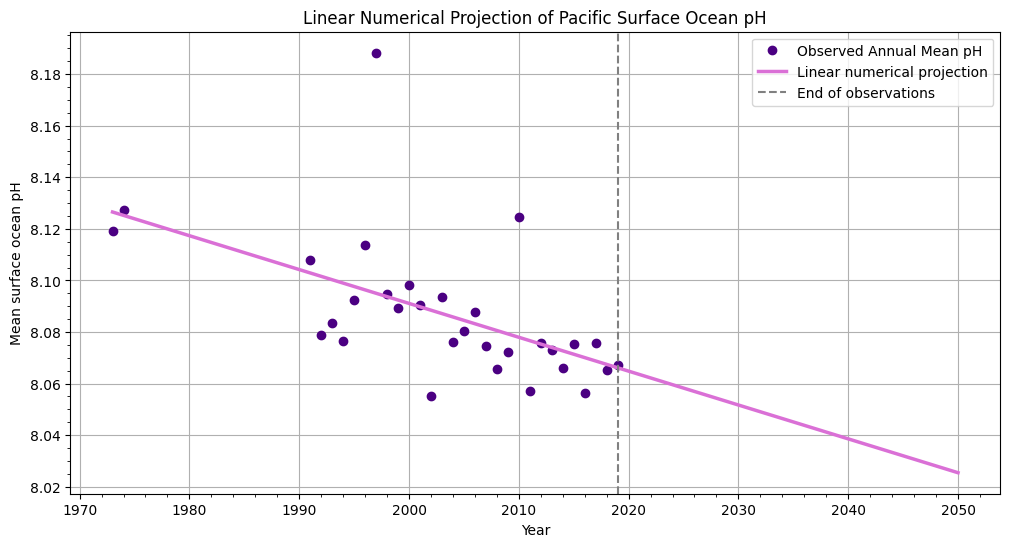

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time, pH, 'o', label='Observed Annual Mean pH', color='indigo')
plt.plot(future_years, future_pH, '-', color='orchid', linewidth=2.5, label='Linear numerical projection')
plt.axvline(x=time.max(), color='grey', linestyle='--', label='End of observations')
plt.xlabel('Year')
plt.ylabel('Mean surface ocean pH')
plt.title('Linear Numerical Projection of Pacific Surface Ocean pH')
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.show()

In [ ]:
#PRINT PROJECTED pH VALUES FOR KEY YEARS

for year in [2030, 2040, 2050]:
    projected_pH = intercept + slope * year
    print(f"Projected pH in {year}: {projected_pH:.4f}")

Projected pH in 2030: 8.0517
Projected pH in 2040: 8.0386
Projected pH in 2050: 8.0254


In [ ]:
#MONTE CARLO SIMULATION FOR 2050 pH UNCERTAINITY

np.random.seed(42)

n_simulations = 10000
target_year = 2050

residuals = pH - pH_fit
residual_std = np.std(residuals)

simulated_slopes = np.random.normal(slope, std_err, n_simulations)
simulated_intercepts = np.random.normal(intercept, residual_std, n_simulations)

simulated_2050_pH = simulated_intercepts + simulated_slopes * target_year

mean_2050 = np.mean(simulated_2050_pH)
lower_2050 = np.percentile(simulated_2050_pH, 2.5)
upper_2050 = np.percentile(simulated_2050_pH, 97.5)

print("Mean simulated pH in 2050: {mean_2050:.4f}")
print("95% confidence interval: ({lower_2050:.4f} to {upper_2050:.4f}")

Mean simulated pH in 2050: {mean_2050:.4f}
95% confidence interval: ({lower_2050:.4f} to {upper_2050:.4f}


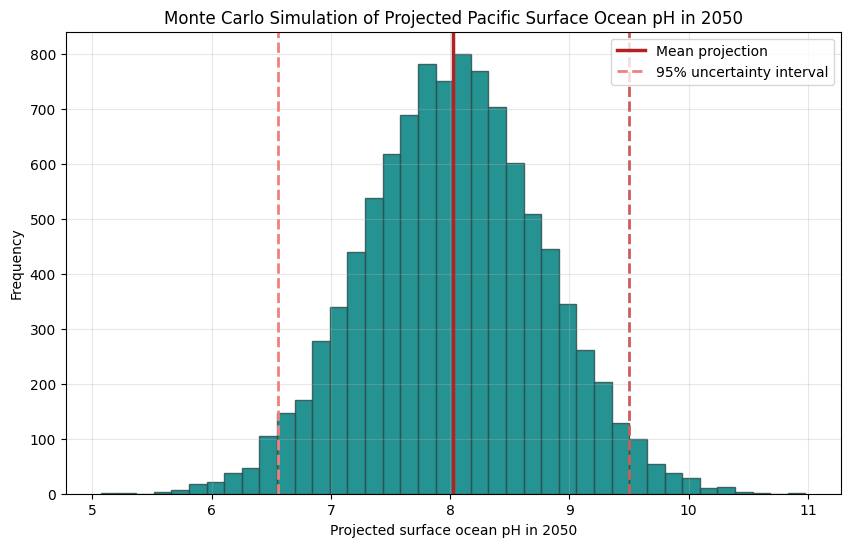

In [ ]:
#PLOT MONTE CARLO DISTRIBUTION FOR 2050 pH

plt.figure(figsize=(10,6))

plt.hist(simulated_2050_pH, bins=40, color='teal', edgecolor='darkslategrey', alpha=0.85)

plt.axvline(mean_2050, color='firebrick', linewidth=2.5, label="Mean projection")

plt.axvline(lower_2050, color='lightcoral', linestyle='--', linewidth=2, label="95% uncertainty interval")

plt.axvline(upper_2050, color='indianred', linestyle='--', linewidth=2)

plt.xlabel("Projected surface ocean pH in 2050")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation of Projected Pacific Surface Ocean pH in 2050")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Monte Carlo Simulation Interpretation

The Monte Carlo simulation was used to represent uncertainty in the future pH projection. Instead of relying on a single projected 2050 pH value, the simulation repeatedly sampled possible model parameters and generated as many 2050 outcomes as plausible for the interpetation model to be well-structured.

The resulting distribution shows the range of possible future pH values based on uncertainty in the fitted historical trend. The 95% interval provides an uncertainty range around the mean projection.

In [ ]:
#MONTE CARLO PROJECTION ENVELOPE TO 2050

future_years_mc = np.arange(int(time.max()), 2051)
n_simulations = 10000

all_simulations = []

for i in range(n_simulations):
    # sample slope uncertainty
    sim_slope = np.random.normal(slope, std_err)

    # keep the projection anchored to the final observed/fitted pH value
    start_pH = intercept + slope * time.max()

    # project forward from the final observation year
    sim_line = start_pH + sim_slope * (future_years_mc - time.max())

    all_simulations.append(sim_line)

all_simulations = np.array(all_simulations)

mean_projection = np.mean(all_simulations, axis=0)
lower_projection = np.percentile(all_simulations, 2.5, axis=0)
upper_projection = np.percentile(all_simulations, 97.5, axis=0)

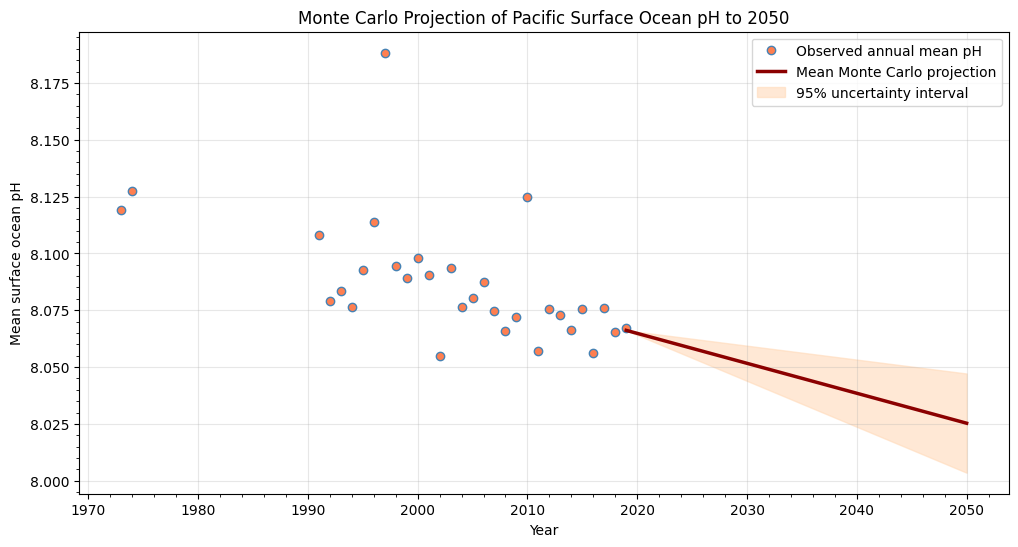

In [ ]:
#PLOT MONTE CARLO UNCERTAINITY ENVELOPE

plt.figure(figsize=(12,6))
plt.plot(time, pH, 'o', color='steelblue', markerfacecolor='coral', markeredgecolor='steelblue', label='Observed annual mean pH')
plt.plot(future_years_mc, mean_projection, color='darkred', linewidth=2.5, label='Mean Monte Carlo projection')
plt.fill_between(future_years_mc, lower_projection, upper_projection, color='peachpuff', alpha=0.6, label='95% uncertainty interval')

plt.xlabel("Year")
plt.ylabel("Mean surface ocean pH")
plt.title("Monte Carlo Projection of Pacific Surface Ocean pH to 2050")
plt.legend()
plt.grid(True, alpha=0.3)
plt.minorticks_on()
plt.show()

## Projection Uncertainty Interpretation

The Monte Carlo uncertainty envelope shows how future projected pH values may vary depending on uncertainty in the model. The central line indicates the mean projection, while the shaded region represents the 95% uncertainty interval.

A widening envelope over time demonstrates that uncertainty increases further into the future. This is expected because small uncertainties in the estimated trend become larger when projected many years ahead - for example, in our case when we consider pH values till 2050.

## Limitations

This analysis has several limitations. First, the GLODAP Pacific dataset is based on cruise observations, meaning the data are not sampled at perfectly regular time intervals or from one fixed location. This may lead to the introduction of spatial and temporal sampling bias.

Second, the analysis uses annual mean values across a broad Pacific region, which can mask regional differences in ocean acidification. Surface pH can vary with latitude, temperature, salinity, biological productivity and ocean circulation.

Third, the numerical model assumes a linear continuation of the historical trend. In reality, future ocean acidification will most likely depend on atmospheric CO₂ emissions, ocean buffering capacity, circulation changes and biological feedbacks.

Finally, the Monte Carlo simulation estimates statistical uncertainty around the trend but does not fully represent all physical, chemical and ecological uncertainties involved in future ocean acidification.

## Conclusion

This project used the GLODAPv2.2021 Pacific Ocean dataset to investigate long-term patterns in Pacific surface ocean acidification. Time series analysis was used to examine historical variation in pH over a period of time, numerical modelling was used to extend the observed trend into the future, and Monte Carlo simulation was used to estimate uncertainty in projected pH values.

Overall, the analysis provides a data-driven approach to understanding changes in Pacific surface ocean carbonate chemistry and demonstrates how historical observations can be used to explore possible future acidification trends.



# Reflection

This project provided an opportunity to apply data science techniques to a real-world environmental problem by investigating long-term Pacific Ocean acidification trends. I selected this topic for the Data Science Fair becayse ocean acidification is one of the most significant consequences of rising atmospheric carbon dioxdie. As someone interested in marine environmental systems, I wanted to explore how effective long-term observational datasets could be used to quantify environmental changes and future projections. This project allowed me to use computational analysis to examine measurable trends in ocean chemistry, rather than simply describing the issue conceptually.

One of the most important aspects of this project was working with a real scientific dataset rather than simplified classroom data. I used the GLODAPv2.2021 Pacific Ocean observational carbonate chemistry dataset and cleaned the data to focus specifically on surface observations (≤10 m depth), as these are most relevant for examining ocean-atmosphere interactions and ecological impacts. In order to prepare the dataset, I carefully filtered, converted data, handled missing values, and aggregated annual means, which eventually helped strengthen my understanding of data preprocessing and the importance of preparing raw datasets before analysis.

This project also significantly improved my technical coding skills in Python. I used Pandas and NumPy for data handling, Matplotlib for visualisation, and SciPy for statistical modelling. Application of time-series analysis helped me movev beyond simple plotting and instead investigate the structure of the data more critically. Frequency spectrum analysis and low-pass filtering were particularly useful for separating long-term signals from short-term variability, helping me better understand how observational noise can obscure broader environmental trends.

Linear regression provided a clear and interpretable way to quantify the rate of Pacific surface ocean acidification, showing a statistically significant decline in pH over time. Further, extending this analysis into numerical modelling allowed me to project future pH values under the assumption that historical trends continue. With the addition of Monte Carlo simulation, introduced uncertainty analysis, which I found especially valuable because environmental systems are inherently variable, and deterministic predictions alone can be misleading. Incorporating an uncertainty analysis made the project more scientifically robust and analytical, highlighting the importance of communicating confidence rather than presenting exact future outcomes.

One of the challenges I encountered was balancing model sophistication with interpretability. While more complex predictive models and different approaches could have been explored, I chose methods that were computationally manageable, scientifically as well as analytically explainable, and aligned with the course content. Another challenge was ensuring that conclusions remained accurate without overstating and expanding explanation about what the model could prove. For example, even though the analysis identified a statistically significant declining pH trend, it does not directly establish causation or account for future emissions scenarios, nonlinear ocean responses, or biological feedbacks.

A limitation of this project is that the predictive modelling assumes that historical linear trends will continue, which might oversimplify future ocean chemistry behaviour. In addition to this, the analysis focuses only on Pacific surface observations, meaning we cannot conclude it to be generalised towards the global ocean chemistry without caution. Future improvements could include incorporating additional environmental variables such as dissolved inorganic carbon, alkalinity, or temperature, or applying more advanced nonlinear forecasting approaches.

Overall, this project helped in enhancing both my technical data science skills and my ability to critically interpret environmental datasets. It demonstrated how computational analysis can be used not only to detect long-term environmental change, but also to communicate uncertainty and support evidence-based scientific understanding.


